## 📚 Índice do Notebook

1. [📊 Automatic IDF Graphs – Análise Exploratória](#-automatic-idf-graphs--análise-exploratória)
2. [🧠 O que é esta biblioteca?](#-o-que-é-esta-biblioteca)
3. [❓ Qual problema ela resolve?](#-qual-problema-ela-resolve)
4. [🛠️ O que este notebook faz?](#-o-que-este-notebook-faz)
5. [⚙️ Instalação e configuração do ambiente](#-instalação-e-configuração-do-ambiente)
6. [📌📆 Requisição de dados brutos de precipitação](#-requisição-de-dados-brutos-de-precipitação)
   - [🛠️ Script para baixar dados (INMET e CEMADEN)](#-script-para-baixar-dados-inmet-e-cemaden)
   - [✅ Passos para rodar o script](#-passos-para-rodar-o-script)
   - [🖥️ Exemplo de uso](#-exemplo-de-uso)
   - [📌 Dúvidas e suporte](#-dúvidas-e-suporte)
7. [📋 Preenchimento de Falhas nos Dados](#-preenchimento-de-falhas-nos-dados)
   - [🗓️ Interpolação Sazonal](#-interpolação-sazonal)
   - [🛰️ Uso de Dataset Auxiliar](#-uso-de-dataset-auxiliar)
   - [🧠 Quando usar o quê?](#-quando-usar-o-quê)
8. [🗃️ Visualização e Análise Inicial dos Dados](#-visualização-e-análise-inicial-dos-dados)
   - [📊 O que é analisado?](#-o-que-é-analisado)
   - [🌧️ Distribuição](#-distribuição)
   - [🎯 P90](#-p90)
   - [📊🆚📊 Dupla Massa](#-dupla-massa)
9. [🔗 Análise de Correlação da Precipitação](#-análise-de-correlação-da-precipitação)
10. [🌊🚨 Obtenção de Dados Extremos](#-obtenção-de-dados-extremos)
    - [🧩 Tipos de Dados Utilizados](#-tipos-de-dados-utilizados)
    - [🔍 Resultado](#-resultado)
    - [🗓️ Dados Diários](#-dados-diários)
    - [⏰ Dados Subdiários (1h a 24h)](#-dados-subdiários-1h-a-24h)
    - [⏰ Dados Subdiários (5min a 30min)](#-dados-subdiários-5min-a-30min)
11. [📊 Distribuição Estatística da Precipitação](#-distribuição-estatística-da-precipitação)
12. [📈 Geração da Curva IDF Histórica](#-geração-da-curva-idf)
13. [🛠️ Correção de Viés para Projeções Futuras](#-correção-de-viés-para-projeções-futuras)

# 📊 Automatic IDF Graphs – Análise Exploratória

Bem-vindo ao notebook de exploração da biblioteca **Automatic-IDF-Graphs** 🚀

<br>

## 🧠 O que é esta biblioteca?

A `idf_analysis` é uma biblioteca Python voltada à **geração automática de curvas IDF (Intensidade-Duração-Frequência)** a partir de dados históricos ou projeções climáticas. Ela auxilia na construção de curvas que são fundamentais para:

- Projetos de drenagem urbana e rural 🌧️
- Dimensionamento de obras hidráulicas 🏗️
- Estudos de impacto climático 📉

<br>

## ❓ Qual problema ela resolve?

Tradicionalmente, gerar curvas IDF demanda muito tempo e envolvimento manual com dados pluviométricos. A `idf_analysis` automatiza:

- 📥 Coleta e tratamento dos dados
- 📈 Análise estatística e ajuste de distribuições
- 📐 Geração das curvas e tabelas
- 📊 Visualização gráfica

<br>

## 🛠️ O que este notebook faz?

Neste notebook, vamos:

- 🔍 Importar e explorar dados de exemplo  
- 📚 Demonstrar as principais funções da biblioteca  
- 📊 Gerar gráficos e curvas IDF com base em dados reais  
- ✅ Validar resultados com visualizações claras  


> 💡 *Este é um ponto de partida para entender e testar a biblioteca antes de aplicá-la em casos reais.*

#### Seguiremos um passo a passo claro, desde instalações até a visualização dos dados.

<br>

---


## ⚙️ Instalação e configuração do ambiente

Instalamos a biblioteca diretamente do repositório GitHub e incluímos a pasta `src/` no `sys.path` para facilitar a importação dos módulos locais.


In [4]:
import sys
import warnings
warnings.filterwarnings('ignore')

print("Instalando a biblioteca...\n")
%pip install --quiet -e ..
sys.path.append('../src')

print("\nInstalação concluída!")

Instalando a biblioteca...

Note: you may need to restart the kernel to use updated packages.

Instalação concluída!


---
## 📌📆 Requisitando dados brutos de precipitação para a análise.

### 🛠️ Como usar o script interativo para baixar dados (INMET, CEMADEN e CLIMBra)

Este projeto inclui um script interativo para facilitar o download de dados meteorológicos do INMET e CEMADEN, além das projeções históricas e futuras do CLIMBra.

*⚠️ Importante*: As funções de download usam menus interativos via terminal, que **não funcionam dentro de notebooks Jupyter**, especialmente no Windows.

#### ✅ Passos para rodar o script

1.  **Abra um terminal** (Prompt de Comando, PowerShell, terminal do VSCode, etc.)
2.  Navegue até a raiz do projeto (onde está a pasta `scripts/`):
    ```bash
    cd /caminho/para/Automatic-IDF-Graphs
    ```
3.  Execute o script:
    ```bash
    python scripts/download_data.py
    ```
4.  Você verá um menu interativo para escolher entre baixar dados do INMET, do CEMADEN ou do CLIMBra, e depois escolher parâmetros como estado, cidade, estação e período.

<br>

### ↪️ Alternativa: Acesso direto aos dados

Se preferir, você também pode requisitar os dados diretamente dos portais oficiais de cada instituição. Esta pode ser uma boa opção para explorar os dados visualmente antes de baixar ou para downloads mais específicos.

* **CEMADEN:** [https://mapainterativo.cemaden.gov.br](https://mapainterativo.cemaden.gov.br)
* **INMET:** [https://portal.inmet.gov.br](https://portal.inmet.gov.br)
* **CLIMBra:** [https://www.scidb.cn/en/detail?dataSetId=609b7ff93f0d4d1a9ba6eb709027c6ad](https://www.scidb.cn/en/detail?dataSetId=609b7ff93f0d4d1a9ba6eb709027c6ad)

<br>

### 🖥️ Exemplo de uso do script

Após rodar o script, o terminal mostrará algo assim:

```bash
? Qual base de dados deseja baixar? (Use as setas ↑ ↓ para navegar)
❯ CEMADEN
  INMET
  CLIMBra

✅ Token recebido com sucesso!

? Selecione um estado (UF):
❯ SP
  RJ
  MG
  ...
```

<br>

### 📌 Dúvidas e suporte
Se tiver problemas ou sugestões, abra uma issue no GitHub.

---
> ⚠️ *Nesse notebook exploratório foram utilizados cinco bases de dados. Dentre elas, temos duas frentes de análise:
- _Mirante de Santana, São Paulo (INMET, horário, 2014-2024)_
- _Mirante de Santana, São Paulo (CEMADEN, 2014-2024)_

<br>

- _Mirante de Santana, São Paulo (INMET, diário, 1980-2013)_
- _CABra467, São Paulo (CLIMBra, histórico, 1980-2013)_
- _CABra467, São Paulo (CLIMBra, ssp245, 2015-2100)_

<br>

> A primeira será utilizada para a geração de IDF's históricas, com preenchimento de falhas e diversas outras funcionalidades. A segunda será voltada para correção de viés e geração de IDF's de projeção futura.

In [1]:

import pandas as pd

from idf_analysis.data.processing import read_csv, verification, fill_missing_data
from idf_analysis.helpers.notebook import precip_summary
from IPython.display import display

# Lendo os DataFrames obtidos
cemaden_df = read_csv(path='../results/cemaden_ac_santana_sao/cemaden_ac_santana_sao_hourly.csv')
inmet_df = read_csv(path='../results/inmet_sao_paulo_mirante/inmet_sao_paulo_mirante_hourly.csv')
inmet_daily_df = read_csv(path='../results/inmet_daily_sao_paulo_mirante/inmet_daily_sao_paulo_mirante_daily.csv')
climbra_hist_df = read_csv(path='../results/CABra467/historical/1980-2013_daily.csv')
climbra_future_df = read_csv(path='../results/CABra467/ssp245/2015-2100_daily.csv')

summary_hourly = pd.concat([
    precip_summary(inmet_df, "INMET Horário"),
    precip_summary(cemaden_df, "CEMADEN"),
    
])
print("📊 Base de dados para IDF's históricas: ")
display(summary_hourly.style.format(precision=2))

summary_daily = pd.concat([
    precip_summary(inmet_daily_df, "INMET Diário"),
    precip_summary(climbra_hist_df, "CLIMBra Histórico"),
    precip_summary(climbra_future_df, "CLIMBra Futuro"),
])

print("📊 Base de dados para correção de viés e IDF's de projeção futura: ")
display(summary_daily.style.format(precision=2))

📊 Base de dados para IDF's históricas: 


,Total registros,Registros > 0,Primeira data,Última data,Precipitação média (mm),Precipitação máxima (mm)
INMET Horário,96456,7267,2014-01-01 00:00:00,2025-01-01 23:00:00,0.17,77.80
CEMADEN,61329,6038,2014-01-01 00:00:00,2025-01-01 23:00:00,0.12,45.00


📊 Base de dados para correção de viés e IDF's de projeção futura: 


,Total registros,Registros > 0,Primeira data,Última data,Precipitação média (mm),Precipitação máxima (mm)
INMET Diário,12419,4594,1980-01-01 00:00:00,2013-12-31 00:00:00,4.46,151.80
CLIMBra Histórico,12419,5475,1980-01-01 00:00:00,2013-12-31 00:00:00,4.15,128.23
CLIMBra Futuro,31411,13809,2015-01-01 00:00:00,2100-12-31 00:00:00,4.32,149.90


---
## 📋 Preenchimento de Falhas nos Dados

Falhas em séries de precipitação são comuns e devem ser tratadas para garantir análises consistentes. A biblioteca oferece dois métodos principais:

### 1. 🗓️ Interpolação Sazonal
Preenche valores faltantes com base em outros anos no mesmo mês ou estação.  
✅ Ideal para falhas pontuais em séries longas (≥10 anos).  
🎯 Preserva o comportamento sazonal natural da precipitação.

### 2. 🛰️ Uso de Dataset Auxiliar
Usa dados de estações próximas via regressão linear ou múltipla.  
✅ Útil para falhas longas ou estações com boa correlação geográfica.

### 🧠 Quando usar o quê?
- Use **Interpolação Sazonal** para falhas curtas em séries bem consolidadas.  
- Use **Dataset Auxiliar** quando há estações vizinhas confiáveis e falhas extensas.

In [2]:
# Verificando falhas
verification(df=cemaden_df,frequency='hourly')
verification(df=inmet_df,frequency='hourly');

[WARNING] Série incompleta. Períodos faltando: 35127

[OK] Série completa! Nenhum período faltando.



##### 📑 Nesse caso, a *utlização de um dataset auxiliar* é adequada, pois para a fonte do CEMADEN existem muitos dados faltantes.

In [5]:
cemaden_df = fill_missing_data(df_main=cemaden_df,
                               df_secondary=inmet_df,
                               frequency='hourly',)

# Verificando novamente após o preenchimento
verification(df=cemaden_df, frequency='hourly');
display(precip_summary(cemaden_df,'CEMADEN sem falhas').style.format(precision=2))
print("\n✅ Observe que o número de registros aumentou de 61329 para 96456.")

[OK] Série completa! Nenhum período faltando.



,Total registros,Registros > 0,Primeira data,Última data,Precipitação média (mm),Precipitação máxima (mm)
CEMADEN sem falhas,96456,26580,2014-01-01 00:00:00,2025-01-01 23:00:00,0.14,45.00



✅ Observe que o número de registros aumentou de 61329 para 96456.


##### ↪️ Caso queira utilizar a interpolação sazonal (não recomendada para uma quantidade alta de dados faltantes):

In [7]:
cemaden_interpolated_df = read_csv(path='../results/cemaden_ac_santana_sao/cemaden_ac_santana_sao_hourly.csv')

# Verificando falhas antes do preenchimento
verification(df=cemaden_interpolated_df, frequency='hourly');

cemaden_interpolated_df = fill_missing_data(df_main=cemaden_interpolated_df,
                               frequency='hourly',)

# Verificando novamente após o preenchimento
verification(df=cemaden_interpolated_df, frequency='hourly');

[WARNING] Série incompleta. Períodos faltando: 35127

[OK] Série completa! Nenhum período faltando.



---
## 🗃️ Visualização e Análise Inicial dos Dados

Antes de ajustar modelos ou gerar curvas, é essencial entender o comportamento bruto da precipitação.

### 📊 O que é analisado?

- **Distribuição dos dados (histograma)**  
  Visualiza como os valores de chuva se espalham — identifica padrões e extremos.

- **P90 (Percentil 90%)**  
  Valor acima do qual estão os 10% maiores registros. Indica eventos intensos.

- **Gráfico de Dupla Massa**  
  Compara o acumulado de uma estação com a média das demais. Verifica a consistência dos dados.

### 🌧️ Distribuição

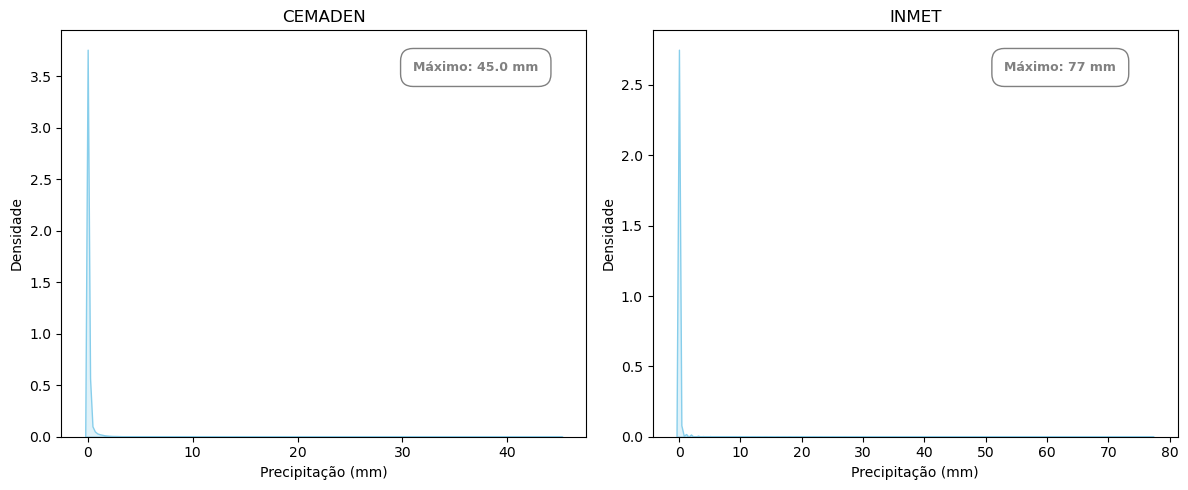

In [6]:

from idf_analysis.visualization.plots import distribution_plot_df
from idf_analysis.analysis.historical.validation import p90, process_precipitation_series
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

distribution_plot_df(df=cemaden_df, show_max=True, ax=axes[0], display=False)
axes[0].set_title("CEMADEN")

distribution_plot_df(df=inmet_df, show_max=True, ax=axes[1], display=False)
axes[1].set_title("INMET")

plt.tight_layout()
plt.show()

### 🎯 P90

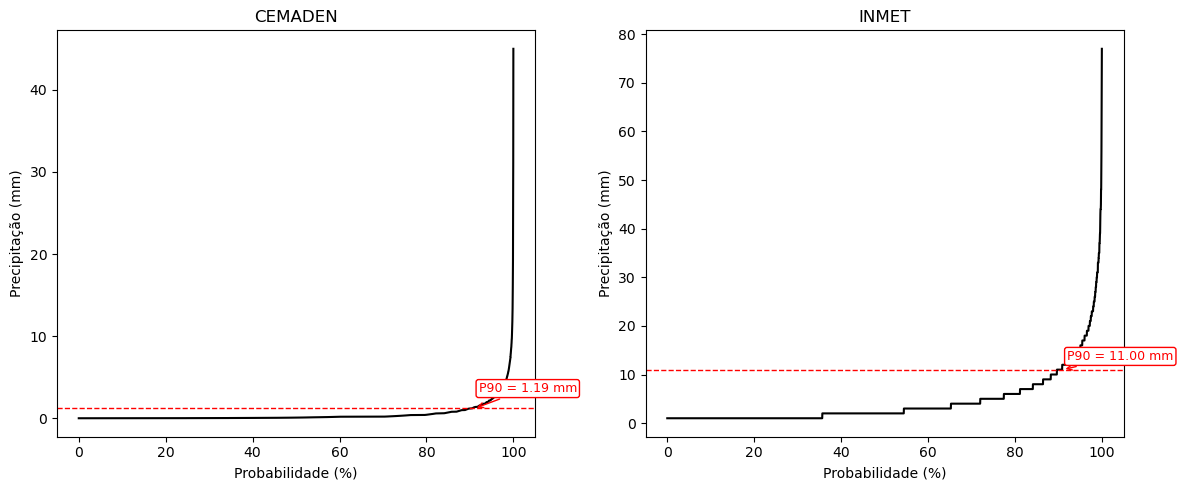

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

_, ax1 = p90(cemaden_df, ax=axes[0], display=False)
axes[0].set_title("CEMADEN")

_, ax2 = p90(inmet_df, ax=axes[1], display=False)
axes[1].set_title("INMET")

plt.tight_layout()
plt.show()

### 📊🆚📊 Cálculo de dupla massa

[OK] Série completa! Nenhum período faltando.

[OK] Série completa! Nenhum período faltando.



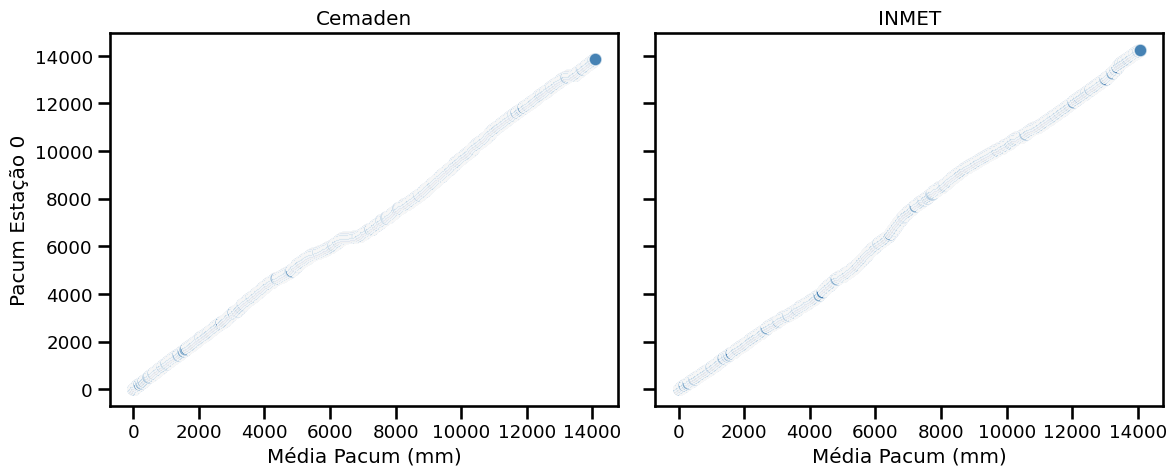

In [7]:
df, (fig, axes) = process_precipitation_series(dataframes=[cemaden_df,inmet_df],
                                plot=False, return_fig=True, frequency='hourly')

axes[0].set_title("Cemaden")
axes[1].set_title("INMET")
plt.tight_layout()
plt.show()

---
## 🔗 Análise de Correlação da Precipitação

### 🎯 Objetivo
Avaliar **o grau de relação** entre séries de precipitação de diferentes estações meteorológicas.  
Essa análise ajuda a:

- Identificar **sincronização de eventos de chuva**.  
- Detectar **redundância ou complementaridade** entre séries.  
- Avaliar **significância estatística** da correlação.

### ⚙️ Como Funciona

1. **📅 Combinação de Séries**  
   - Junta os DataFrames pela coluna/índice `Date`.  
   - Soma valores para datas repetidas (ex.: dados horários → diários).  

2. **📈 Visualização Gráfica**  
   - Gera **pairplots** para analisar dispersão entre as séries.  
   - Pode aplicar **transformação logarítmica** e **linha de regressão** para melhor interpretação.  

3. **🧮 Cálculo Estatístico**  
   - **Matriz de Correlação (r de Pearson)**: mede força da relação linear.  
   - **Matriz de P-valores**: avalia se a correlação é estatisticamente significativa.  

[INFO] Dados horários detectados → agregando para diário...
[INFO] Gerando scatter/regression com 4019 pontos...


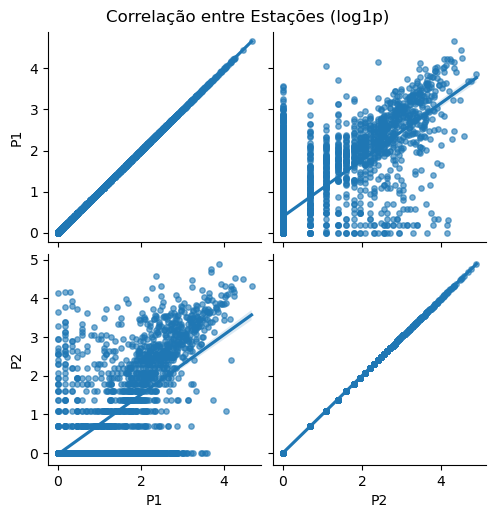


[INFO] ----- Resultados da Correlação -----

Matriz de Correlação (r de Pearson):
       P1     P2
P1 1.0000 0.7342
P2 0.7342 1.0000

Matriz de P-valores:
           P1         P2
P1 1.0000e+00 0.0000e+00
P2 0.0000e+00 1.0000e+00


In [7]:
from idf_analysis.core.correlation import correlation_plots

correlation_plots(cemaden_df, inmet_df);

---
## 📈 Análise de Tendência da Precipitação

### 🎯 Objetivo
Detectar **mudanças sistemáticas** nos padrões de precipitação ao longo do tempo.  
Identifica tendências de longo prazo e avalia sua significância estatística.

### ⚙️ Como Funciona

1. **🧹 Preparação**: Limpa séries temporais e remove valores ausentes.

2. **📊 Testes Mann-Kendall**: Aplica 5 variações do teste para detectar tendências monotônicas:
  - *Original, Hamed-Rao, Yue-Wang, Pre-whitening, Trend-free*

3. **📈 Quantificação**: Calcula Sen's Slope (mm/ano), Tau de Kendall e intervalos de confiança.

4. **🎨 Visualização**: Gráficos de tendência com análise de resíduos e comparações estatísticas.

### 📋 Resultados
- Direção da tendência (crescente/decrescente/sem tendência)
- Significância estatística (p-valor)
- Magnitude da mudança (Sen's slope em mm/ano)
- Comparação entre diferentes metodologias

### ⚠️ Considerações
- **Dados Mínimos**: recomendado ≥20 anos para análise robusta
- **Autocorrelação**: pode inflacionar significância (use testes corrigidos)
- **Outliers**: eventos extremos podem mascarear tendências reais
- **Sazonalidade**: dados anuais reduzem interferência sazonal
- **Múltiplos Testes**: considere correção de Bonferroni para análises em larga escala

In [6]:
from idf_analysis.analysis.historical.validation import max_annual_precipitation
from idf_analysis.analysis.historical.trend import run_trend_analysis,filter_significant_results,get_best_test_per_site



# Essa função será detalhada em seguida
max_annual_inmet_daily = max_annual_precipitation(df=inmet_daily_df, name_file='cemaden_ac_santana_sao', output_dir='../results/cemaden_ac_santana_sao/', frequency='hourly')
max_annual_climbra_hist = max_annual_precipitation(df=climbra_hist_df, name_file='inmet_sao_paulo_mirante', output_dir='../results/inmet_sao_paulo_mirante/', frequency='hourly')

results_df, stats = run_trend_analysis(
    {
        'CLIMBra Histórico': max_annual_climbra_hist,
        'INMET': max_annual_inmet_daily
    }, 
    generate_plots=True,
    output_dir='../results/graphs/trend'
)

# Apenas resultados significativos
significant = filter_significant_results(results_df)

display(significant)


[INFO] Gráficos salvos em: ../results/graphs/trend



,site,test_type,tau,p_value,trend,significant,z_score,s_statistic,variance_s,slope,intercept,ci_lower,ci_upper
7,INMET,yue_wang,0.210227,0.000013,increasing,True,4.360765,111.0,636.297309,0.784286,70.251429,-5.917987,7.486559


---
## 🌊🚨 Obtenção de Dados Extremos

### 🎯 Por que extrair dados extremos?

Para gerar curvas **IDF (Intensidade-Duração-Frequência)** precisas, é necessário identificar os **maiores eventos de precipitação** registrados ao longo do tempo — esses são os chamados **dados extremos**. Eles representam as chuvas mais intensas em diferentes escalas temporais.

### 🧩 Tipos de Dados Utilizados

1. **📅 Dados Diários**  
   - Considera o **maior valor de precipitação por dia** ao longo de cada ano.  
   - Base para desagregações ou análises mais simples.

2. **🕒 Dados Subdiários em Horas**  
   - Dados medidos hora a hora.  
   - Calcula-se o **acumulado máximo** em janelas móveis de:  
     `1h, 3h, 6h, 8h, 10h, 12h, 24h`

3. **🕔 Dados Subdiários em Minutos**  
   - Dados com resolução fina (ex.: a cada 5 ou 10 minutos).  
   - Permite estimar extremos em intervalos curtos:  
     `5min, 10min, 15min, 20min, 25min e 30min`  
   - Ideal para áreas urbanas e estudos de microdrenagem.

### 🔍 Resultado

- Tabelas com **valores máximos por ano** para cada duração.
- Base para ajuste de distribuições estatísticas.

### 🗓️ Dados Diários 

In [8]:
from idf_analysis.analysis.historical.validation import max_annual_precipitation

max_annual_cemaden = max_annual_precipitation(df=cemaden_df, name_file='cemaden_ac_santana_sao', output_dir='../results/cemaden_ac_santana_sao/', frequency='hourly')
max_annual_inmet = max_annual_precipitation(df=inmet_df, name_file='inmet_sao_paulo_mirante', output_dir='../results/inmet_sao_paulo_mirante/', frequency='hourly')

print("\n📊 CEMADEN - Máximos anuais:")
display(max_annual_cemaden)

print("\n📊 INMET - Máximos anuais:")
display(max_annual_inmet)


📊 CEMADEN - Máximos anuais:


,Year,Precipitation
0,2014,67.3700
2,2016,57.6051
3,2017,84.6900
4,2018,70.1800
5,2019,35.9680
6,2020,49.5590
7,2021,39.8215
8,2022,58.2400
9,2023,55.2293
10,2024,63.7800



📊 INMET - Máximos anuais:


,Year,Precipitation
0,2014,73.6
1,2015,87.2
2,2016,82.8
3,2017,120.8
4,2018,96.4
5,2019,98.6
6,2020,143.0
7,2021,55.6
8,2022,64.2
9,2023,64.2


### ⏰ Dados Subdiários (1h, 3h, 6h, 8h, 10h, 12h, 24h)

In [7]:
from idf_analysis.analysis.historical.subdaily import get_max_subdaily_table

incomplete_subdaily_cemaden = get_max_subdaily_table(df=cemaden_df, name_file='cemaden_ac_santana_sao', output_dir='../results/cemaden_ac_santana_sao')

print("\n📊 CEMADEN - Máximos subdiários:")
display(incomplete_subdaily_cemaden)

incomplete_subdaily_inmet = get_max_subdaily_table(df=inmet_df, name_file='inmet_sao_paulo_mirante', output_dir='../results/inmet_sao_paulo_mirante')

print("\n📊 INMET - Máximos subdiários:")
display(incomplete_subdaily_inmet)




[OK] Resultados salvos em: ../results/cemaden_ac_santana_sao/max_subdaily_cemaden_ac_santana_sao.csv

📊 CEMADEN - Máximos subdiários:


,Year,Max_1h,Max_3h,Max_6h,Max_8h,Max_10h,Max_12h,Max_24h
0,2014,45.00,55.46,63.04,64.22,67.36,68.36,119.54
1,2015,43.99,89.54,94.08,94.28,94.48,94.48,104.33
2,2016,25.82,40.08,51.44,58.46,60.39,60.54,64.20
3,2017,26.84,55.56,67.17,67.97,68.35,70.52,87.44
4,2018,12.20,17.70,26.50,34.36,42.61,49.68,74.89
5,2019,25.98,31.88,34.25,36.14,36.14,36.34,46.46
6,2020,12.40,17.54,31.37,32.01,32.42,40.98,50.69
7,2021,11.47,21.08,30.07,36.94,41.95,43.81,57.55
8,2022,37.38,44.45,44.65,44.65,44.65,44.65,62.58
9,2023,30.74,41.03,43.01,43.81,43.81,44.20,56.44



[OK] Resultados salvos em: ../results/inmet_sao_paulo_mirante/max_subdaily_inmet_sao_paulo_mirante.csv

📊 INMET - Máximos subdiários:


,Year,Max_1h,Max_3h,Max_6h,Max_8h,Max_10h,Max_12h,Max_24h
0,2014,45.2,52.0,70.6,71.0,71.0,71.0,118.8
1,2015,77.8,87.2,87.2,87.2,87.2,87.2,100.0
2,2016,39.6,61.2,68.6,94.8,99.8,99.8,99.8
3,2017,64.6,97.0,101.8,113.4,113.4,113.4,121.8
4,2018,29.2,57.6,71.4,71.8,74.4,75.0,99.4
5,2019,67.6,88.0,92.6,94.0,94.2,94.2,126.4
6,2020,44.4,61.8,96.6,115.6,127.0,133.0,150.8
7,2021,31.0,48.4,48.4,48.6,49.4,49.4,63.6
8,2022,44.4,51.4,52.8,52.8,52.8,52.8,74.8
9,2023,56.6,61.8,73.0,73.6,75.4,76.0,81.0


### ⏰ Dados Subdiários (5min, 10min, 15min, 20min, 25min e 30min)

In [9]:
from idf_analysis.analysis.historical.intervals import DisaggregationScenario, get_subdaily_from_disaggregation_factors

var_value = 0.1 # Valor de exemplo para variação de precipitação

subdaily_cemaden = get_subdaily_from_disaggregation_factors(
    df=incomplete_subdaily_cemaden,
    scenario=DisaggregationScenario.BASE,
    var_value=var_value,
    frequency='hourly',
    name_file='cemaden_ac_santana_sao', 
    output_dir='../results/cemaden_ac_santana_sao'
)

print("\n📊 CEMADEN - Subdiários obtidos:")
display(subdaily_cemaden)
        
subdaily_inmet = get_subdaily_from_disaggregation_factors(
    df=incomplete_subdaily_inmet,
    scenario=DisaggregationScenario.BASE,
    var_value=var_value,
    frequency='hourly',
    name_file='inmet_sao_paulo_mirante',
    output_dir='../results/inmet_sao_paulo_mirante'
)

print("\n📊 INMET - Subdiários obtidos:")
display(subdaily_inmet)


[OK] Resultado salvo em: ../results/cemaden_ac_santana_sao/max_subdaily_cemaden_ac_santana_sao_ger.csv

📊 CEMADEN - Subdiários obtidos:


,Year,Max_1h,Max_3h,Max_6h,Max_8h,Max_10h,Max_12h,Max_24h,Max_5min,Max_10min,Max_15min,Max_20min,Max_25min,Max_30min
0,2014,57.24,55.46,98.12,106.29,111.75,115.83,136.28,14.40,22.87,29.65,34.31,38.54,42.35
1,2015,49.95,89.54,85.63,92.77,97.53,101.10,118.94,12.57,19.96,25.88,29.94,33.64,36.97
2,2016,30.74,40.08,52.70,57.09,60.01,62.21,73.19,7.73,12.28,15.92,18.42,20.70,22.75
3,2017,41.87,55.56,71.77,77.75,81.74,84.73,99.68,10.53,16.73,21.69,25.09,28.19,30.98
4,2018,35.86,17.70,61.47,66.59,70.01,72.57,85.37,9.02,14.33,18.57,21.49,24.15,26.53
5,2019,22.25,31.88,38.13,41.31,43.43,45.02,52.96,5.60,8.89,11.52,13.33,14.98,16.46
6,2020,24.27,17.54,41.61,45.07,47.39,49.12,57.79,6.11,9.70,12.57,14.55,16.34,17.96
7,2021,27.55,21.08,47.24,51.17,53.80,55.77,65.61,6.93,11.01,14.27,16.52,18.56,20.39
8,2022,29.96,44.45,51.37,55.65,58.50,60.64,71.34,7.54,11.97,15.52,17.96,20.18,22.17
9,2023,27.02,41.03,46.33,50.19,52.76,54.69,64.34,6.80,10.80,14.00,16.20,18.20,20.00


[OK] Resultado salvo em: ../results/inmet_sao_paulo_mirante/max_subdaily_inmet_sao_paulo_mirante_ger.csv

📊 INMET - Subdiários obtidos:


,Year,Max_1h,Max_3h,Max_6h,Max_8h,Max_10h,Max_12h,Max_24h,Max_5min,Max_10min,Max_15min,Max_20min,Max_25min,Max_30min
0,2014,56.88,52.0,97.51,105.64,111.05,115.12,135.43,14.31,22.73,29.46,34.09,38.30,42.09
1,2015,47.88,87.2,82.08,88.92,93.48,96.90,114.00,12.05,19.13,24.80,28.70,32.24,35.43
2,2016,47.78,61.2,81.92,88.74,93.29,96.71,113.77,12.02,19.09,24.75,28.64,32.18,35.36
3,2017,58.32,97.0,99.97,108.30,113.86,118.02,138.85,14.67,23.30,30.21,34.96,39.27,43.16
4,2018,47.59,57.6,81.59,88.39,92.92,96.32,113.32,11.97,19.02,24.65,28.53,32.05,35.22
5,2019,60.52,88.0,103.75,112.39,118.16,122.48,144.10,15.23,24.18,31.35,36.28,40.75,44.79
6,2020,72.20,61.8,123.78,134.09,140.97,146.13,171.91,18.17,28.85,37.40,43.28,48.62,53.43
7,2021,30.45,48.4,52.20,56.55,59.45,61.63,72.50,7.66,12.17,15.77,18.25,20.51,22.53
8,2022,35.81,51.4,61.40,66.51,69.92,72.48,85.27,9.01,14.31,18.55,21.47,24.12,26.50
9,2023,38.78,61.8,66.48,72.03,75.72,78.49,92.34,9.76,15.50,20.09,23.25,26.12,28.70


---
## 📊 Distribuição Estatística da Precipitação

### 🎯 O que é?

A **distribuição estatística** representa como os valores de precipitação se distribuem ao longo do tempo. Ela é fundamental para compreender a variabilidade dos dados e identificar padrões, tendências e eventos extremos.

### ⏱️ Tipos de Análise

1. **📅 Dados Diários**  
   - Utilizam os totais registrados por dia.  
   - Não exigem parametrização adicional.

2. **🕒 Dados Subdiários (Desagregados)**  
   - Requerem:
     - Um **fator de desagregação** apropriado.
     - A **duração alvo** a ser analisada (ex.: 15 min, 1 h, etc.).


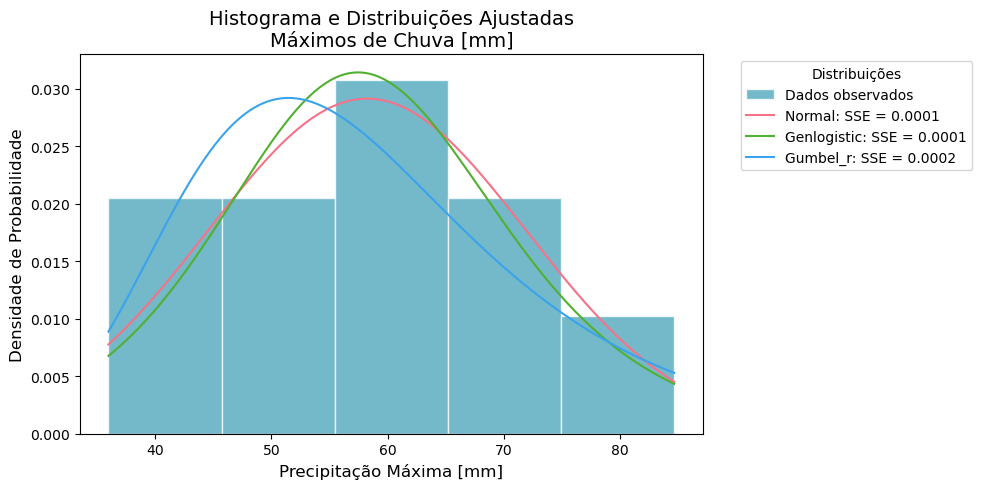

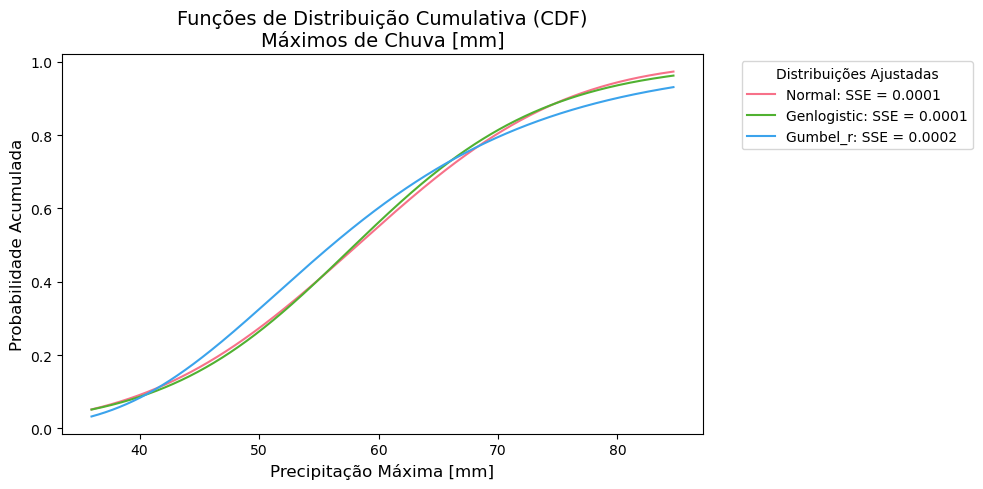

In [10]:
from idf_analysis.core.distributions import get_distribution
import warnings
warnings.filterwarnings('ignore')

# Obtendo a distribuição estatística dos dados diários
get_distribution(data_df=max_annual_cemaden,column_name='Precipitation')


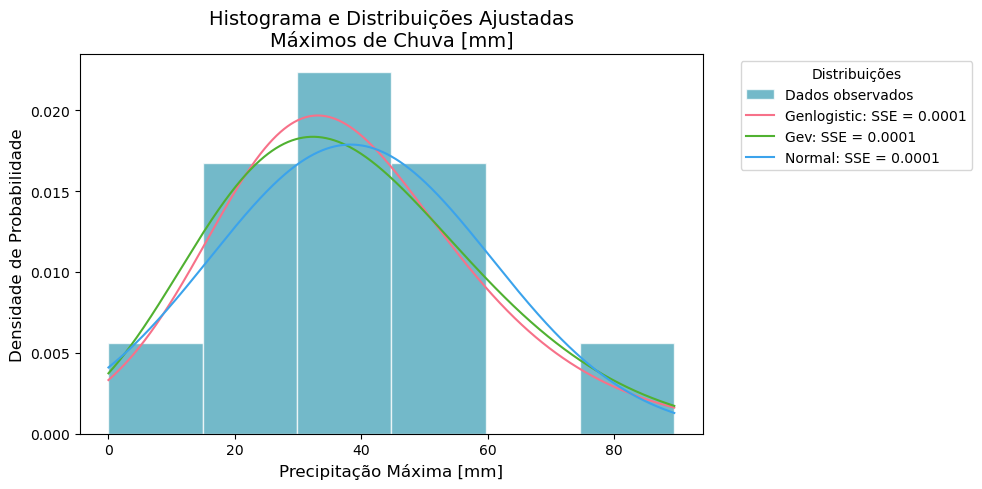

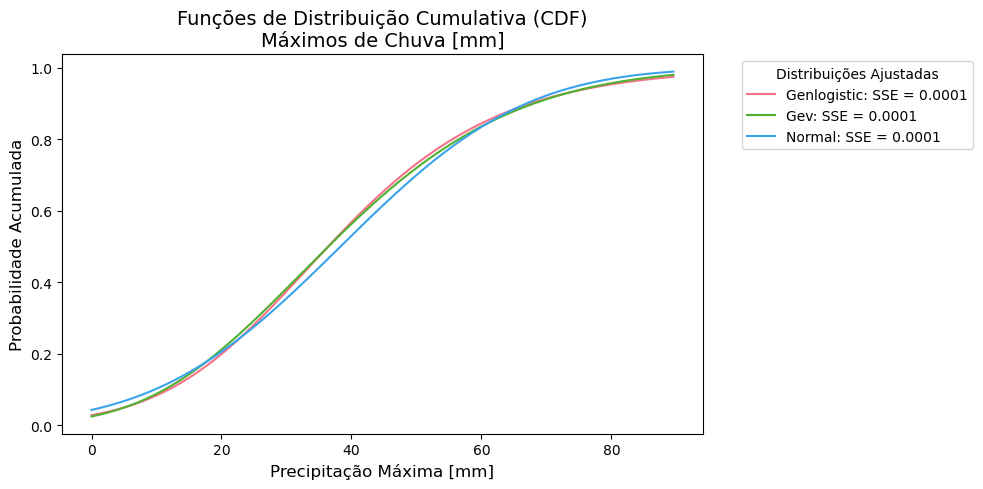

In [11]:
# Obtendo a distribuição estatística dos dados subdiários
get_distribution(data_df=subdaily_cemaden,
                 column_name='Max_3h')

---
## 📈 Geração da Curva IDF Histórica

Agora vamos gerar as **curvas IDF (Intensidade-Duração-Frequência)** a partir dos dados históricos processados.

### 🎯 O que são Curvas IDF?

As curvas IDF estabelecem a relação entre:
- **Intensidade** (mm/h): Taxa de precipitação
- **Duração** (min/h): Tempo do evento chuvoso  
- **Frequência** (anos): Período de retorno

### 🔧 Processo

1. **Ajuste estatístico** dos dados extremos
2. **Calibração dos parâmetros** da equação IDF
3. **Geração das tabelas** e gráficos

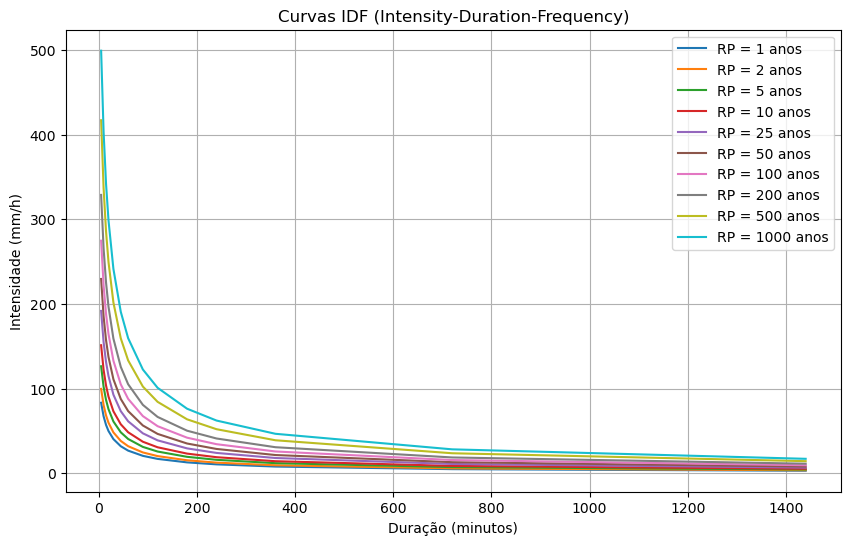

In [12]:
from idf_analysis.analysis.historical.idf import get_final_idf

get_final_idf(
    name_file='cemaden_ac_santana_sao',
    directory='../results/cemaden_ac_santana_sao',
    disag_factor='ger',
    save_file=True,
    plot=True,
);

---
## 🛠️ Correção de Viés para Projeções Futuras

Nesta seção, aplicaremos três métodos de correção de viés aos dados de projeção climática, com o objetivo de aproximar os dados simulados pelos modelos climáticos (GCMs) das observações reais.

### 🎯 Por que corrigir o viés?

Modelos climáticos frequentemente apresentam desvios sistemáticos em relação às observações. A correção de viés é essencial para:
- Aumentar a confiabilidade das projeções futuras
- Alinhar estatisticamente os dados simulados com os observados
- Reduzir erros em aplicações hidrológicas e climáticas

### ⚙️ Métodos Aplicados

#### 🟦 DBC Percentílico (Delta Bias Correction Percentílico)

Este método realiza a correção da distribuição dos dados projetados com base nos percentis da série observada.  
Ele **ajusta os dados futuros simulados preservando a variação relativa (delta)** entre os cenários histórico e futuro do GCM.

✅ Ideal quando se quer **manter a tendência do modelo** climático, mas corrigir o desvio estatístico em relação às observações.  
🔍 Recomendado para análises que envolvem **mudanças relativas nas chuvas** ao longo do tempo.



[INFO] Período da série: 1961-01-01 00:00:00 até 2025-03-01 00:00:00
[INFO] Períodos esperados: 23436
[INFO] Entradas no DataFrame: 23436

[OK] Série completa! Nenhum período faltando.


[INFO] Período da série: 1961-01-01 00:00:00 até 2005-12-30 00:00:00
[INFO] Períodos esperados: 16435
[INFO] Entradas no DataFrame: 16435

[OK] Série completa! Nenhum período faltando.

Período comum considerado: 01-01-1961 até 30-12-2005

[INFO] Período da série: 2006-01-01 00:00:00 até 2099-11-30 00:00:00
[INFO] Períodos esperados: 34302
[INFO] Entradas no DataFrame: 34302

[OK] Série completa! Nenhum período faltando.



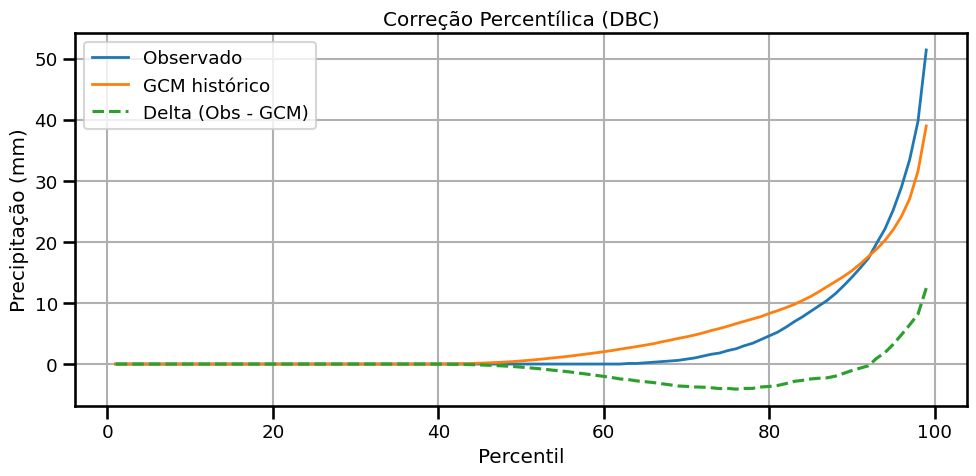


📊 DBC Percentilico - INMET Santana:


,Date,Precipitation Original,Precipitation
0,01-01-06,0.564960,0.000000
1,02-01-06,22.140406,25.524925
2,03-01-06,21.383104,24.192877
3,04-01-06,0.000000,0.000000
4,05-01-06,0.000000,0.000000
5,06-01-06,0.481118,0.004503
6,07-01-06,8.536477,4.955301
7,08-01-06,19.688452,21.204724
8,09-01-06,19.761736,21.317320
9,10-01-06,0.797462,0.000000


In [15]:
from idf_analysis.analysis.projection.dbc import dbc_percentilico

dbc_corrected_df = dbc_percentilico(
    name_obs='inmet_santana',
    name_gcm_baseline='HADGEM_baseline',
    name_gcm_future='HADGEM_rcp45',
    dir_obs='../results/inmet_santana',
    dir_gcm='../datasets/GCM',
    plot=True,
    save_csv_path='../results/inmet_santana/inmet_santana_future_dbc.csv'
);

print("\n📊 DBC Percentilico - INMET Santana:")
display(dbc_corrected_df.head(10))

#### 🟩 Quantile Mapping (Mapeamento de Quantis)

Esse método mapeia os quantis dos dados simulados para os quantis dos dados observados, corrigindo a distribuição completa da variável.

✅ Corrige **toda a distribuição estatística** (não apenas média ou desvio), lidando bem com extremos.

🔍 Muito útil para aplicações que exigem boa representação dos **eventos extremos de precipitação**.



[INFO] Período da série: 1961-01-01 00:00:00 até 2025-03-01 00:00:00
[INFO] Períodos esperados: 23436
[INFO] Entradas no DataFrame: 23436

[OK] Série completa! Nenhum período faltando.


[INFO] Período da série: 1961-01-01 00:00:00 até 2005-12-30 00:00:00
[INFO] Períodos esperados: 16435
[INFO] Entradas no DataFrame: 16435

[OK] Série completa! Nenhum período faltando.

Período comum considerado: 01-01-1961 até 30-12-2005

[INFO] Período da série: 2006-01-01 00:00:00 até 2099-11-30 00:00:00
[INFO] Períodos esperados: 34302
[INFO] Entradas no DataFrame: 34302

[OK] Série completa! Nenhum período faltando.



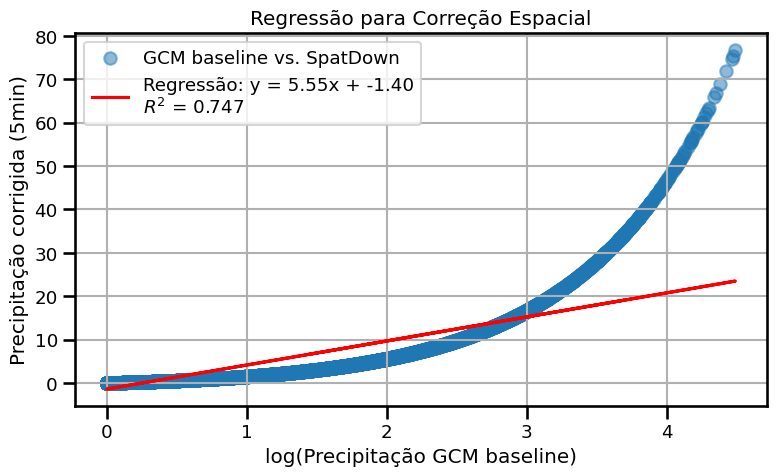


📊 Quantile Mapping - INMET Santana:


,Date,Precipitation Original,Precipitation
0,01-01-06,0.564960,1.078695
1,02-01-06,22.140406,16.016629
2,03-01-06,21.383104,15.832110
3,04-01-06,0.000000,0.000000
4,05-01-06,0.000000,0.000000
5,06-01-06,0.481118,0.773343
6,07-01-06,8.536477,11.100816
7,08-01-06,19.688452,15.395511
8,09-01-06,19.761736,15.415120
9,10-01-06,0.797462,1.846827


In [16]:
from idf_analysis.analysis.projection.quantile_mapping import quantile_mapping

qm_corrected_df = quantile_mapping(
    name_obs='inmet_santana',
    name_gcm_baseline='HADGEM_baseline',
    name_gcm_future='HADGEM_rcp45',
    dir_obs='../results/inmet_santana',
    dir_gcm='../datasets/GCM',
    plot=True,
    save_csv_path='../results/inmet_santana/inmet_santana_future.csv'
);

print("\n📊 Quantile Mapping - INMET Santana:")
display(qm_corrected_df.head(10))

#### 🟥 EQM Downscaling (Empirical Quantile Mapping com Downscaling)

Variante do Quantile Mapping que, além de corrigir o viés, **permite redução de escala (downscaling)**, ajustando os dados projetados para uma resolução temporal ou espacial mais próxima das observações.

✅ Útil quando o GCM apresenta resolução grosseira e se deseja detalhamento local mais preciso.

🔍 Indicado para estudos de impacto climático regional, onde a granularidade dos dados é fundamental.


Iniciando o processo de Downscaling EQM...

Passo 1: Carregando e preparando os dados anuais...

[INFO] Preparando dados históricos.
[OK] Série completa! Nenhum período faltando.

[OK] Série completa! Nenhum período faltando.


Período comum considerado: 01-01-1961 até 30-12-2005

[INFO] Preparando dados futuros.
[OK] Série completa! Nenhum período faltando.


[INFO] Calculando máximos anuais para 'inmet_santana' com frequência: 'daily'
[INFO] Máximos anuais calculados para 45 anos.
[INFO] Após remoção de outliers: 43 anos restantes.
[OK] Arquivo salvo em: ../results/inmet_santana\max_daily_inmet_santana.csv


[INFO] Calculando máximos anuais para 'HADGEM_baseline' com frequência: 'daily'
[INFO] Máximos anuais calculados para 45 anos.
[INFO] Após remoção de outliers: 45 anos restantes.
[OK] Arquivo salvo em: ../datasets/GCM\max_daily_HADGEM_baseline.csv


[INFO] Calculando máximos anuais para 'HADGEM_rcp45' com frequência: 'daily'
[INFO] Máximos anuais calculados para 94 anos.
[INFO] A

C:\Users\pedro\AppData\Local\Temp\ipykernel_25408\550227964.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


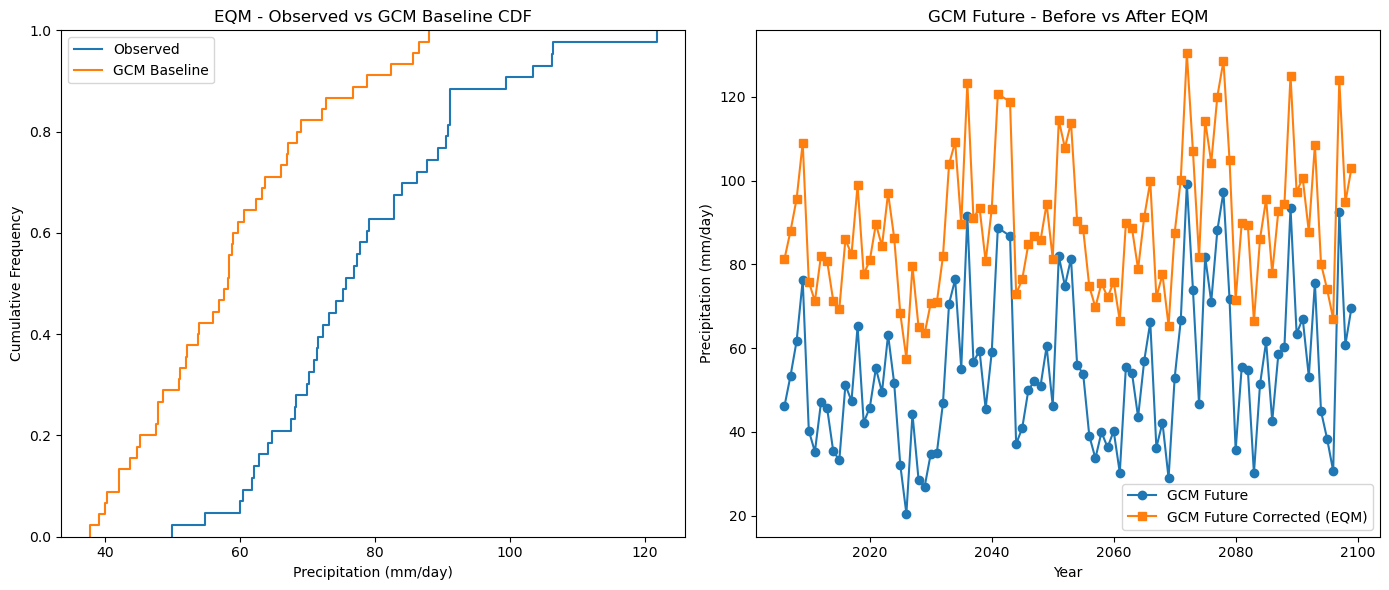

In [1]:
from idf_analysis.analysis.projection.eqm import eqm_downscaling
from idf_analysis.analysis.historical.intervals import DisaggregationScenario

fig, axes = eqm_downscaling(
    name_obs='inmet_santana', 
    name_gcm_baseline='HADGEM_baseline', 
    name_gcm_future='HADGEM_rcp45', 
    dir_obs='../results/inmet_santana', 
    dir_gcm='../datasets/GCM',
    plot=True
    )

fig.show()